# Multilayer Perceptron (MLP) - TensorFlow / Keras


TensorFlow: 2.20.0


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315 (5.14 KB)

 Trainable params: 1,315 (5.14 KB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Final validation accuracy: 0.9210526347160339


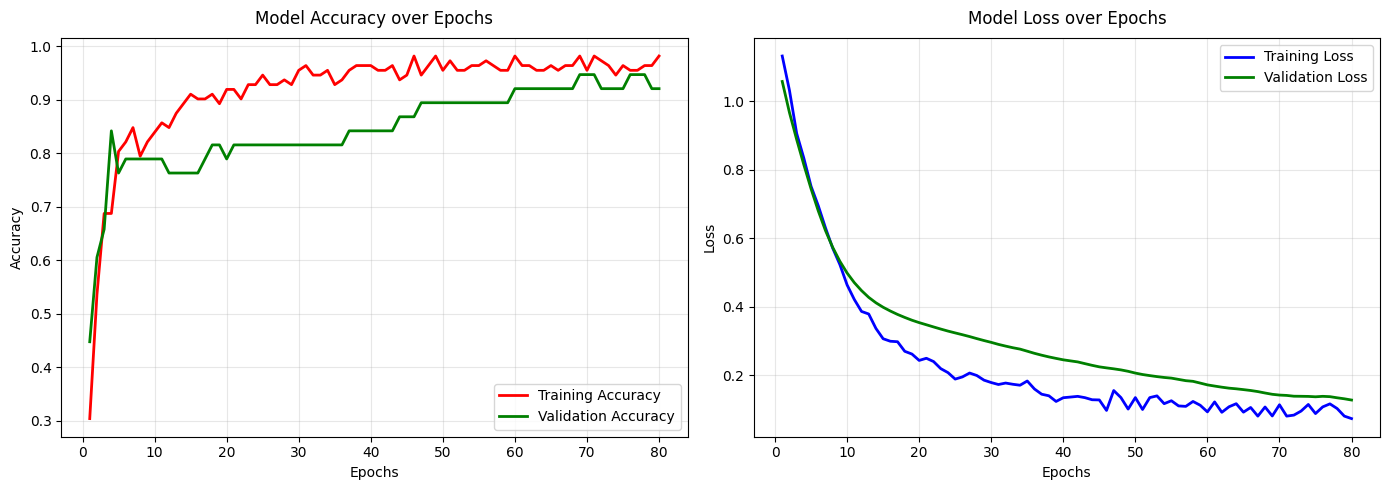

In [14]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt # FIX: Added missing import for plotting

# ---------------------------------------------------------
# 1. ENVIRONMENT SETUP
# Set random seeds for reproducibility (ensures we get the
# same results every time we run the script)
# ---------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(SEED)
print(f"TensorFlow: {tf.__version__}")

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 2. DATA PREPARATION
# ---------------------------------------------------------
# Load the Iris dataset (4 features, 3 target classes)
iris = load_iris()

# FIX: Added line breaks.
# Standardize features (mean=0, variance=1). This is crucial
# for Neural Networks to learn effectively.
X = StandardScaler().fit_transform(iris.data).astype("float32")
y = iris.target.astype("int64")

# Split into training (75%) and testing/validation (25%)
# stratify=y ensures both sets have the exact same proportion of each class
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

# ---------------------------------------------------------
# 3. MODEL ARCHITECTURE (The Multilayer Perceptron)
# ---------------------------------------------------------
# FIX: Added line break for model initialization.
model = keras.Sequential([
    # Input layer: matches the 4 features of the Iris dataset
    layers.Input(shape=(4,)),

    # Hidden Layer 1: 32 neurons, ReLU activation adds non-linearity
    layers.Dense(32, activation="relu"),

    # Dropout Layer: Randomly disables 15% of neurons to prevent overfitting
    layers.Dropout(0.15),

    # Hidden Layer 2: 32 neurons, extracting higher-level patterns
    layers.Dense(32, activation="relu"),

    # Output Layer: 3 neurons (one for each class).
    # Softmax converts raw outputs into percentage probabilities.
    layers.Dense(3, activation="softmax"),
])

# Compile defines how the model learns
model.compile(
    # AdamW optimizer adjusts the learning rate automatically
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    # Sparse Categorical Crossentropy is used when labels are integers (0, 1, 2)
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ---------------------------------------------------------
# 4. TRAINING THE MODEL (FIX: This block was missing entirely)
# ---------------------------------------------------------
print("\nStarting Training...")
# We must capture the output of model.fit() in the 'history' variable
# so we have data to plot in the next step.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=16,
    verbose=0 # Set to 1 or 2 if you want to see the progress bar in the console
)
print("Final validation accuracy:", history.history["val_accuracy"][-1])

# ---------------------------------------------------------
# 5. VISUALIZING THE RESULTS
# ---------------------------------------------------------
# Set up the plotting environment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Plot Training & Validation Accuracy
ax1.plot(epochs_range, history.history['accuracy'], label='Training Accuracy', color='r', lw=2)
ax1.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', color='g', lw=2)
ax1.set_title('Model Accuracy over Epochs', fontsize=12, pad=10)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Plot Training & Validation Loss
ax2.plot(epochs_range, history.history['loss'], label='Training Loss', color='b', lw=2)
ax2.plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='g', lw=2)
ax2.set_title('Model Loss over Epochs', fontsize=12, pad=10)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

# Ensure tight layout and render
plt.tight_layout()
plt.show()